In [1]:
# IN04: Agent Design Principles -- Single-Agent vs Multi-Agent

In [2]:
# Objectives

# By the end of this notebook you will be able to:
# - Describe the five components of an AI agent: planning, memory, state, tool calling, action
# - Build a single-agent system for the Walmart Retail Assistant use case using LangGraph
# - Identify the conditions under which single-agent design breaks down
# - Design and build a multi-agent system with a coordinator and specialist sub-agents
# - Apply a five-dimension scoring model to choose between single-agent and multi-agent

# Deliverable: agent_design_worksheet.txt

In [3]:
# For a Walmart Retail Assistant, should we use one AI agent to handle everything, or multiple specialised agents?

In [4]:
import os, json, time
from pathlib import Path
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from typing import TypedDict, Annotated

load_dotenv(override=True)
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

llm = ChatOpenAI(model='gpt-4-turbo', api_key=OPENAI_API_KEY, temperature=0)
print('LLM ready:', llm.model_name)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM ready: gpt-4-turbo


In [5]:
# Walmart Retail Tools

@tool
def search_product(query: str) -> str: # search_product("MiLk")
    """Search Walmart product catalog. Returns product name, price, aisle, and SKU."""
    catalog = {
        'milk':    'Great Value Whole Milk 1gal    | $3.98 | Aisle 12 | SKU: GV-MILK-1G',
        'bread':   'Great Value White Bread 20oz   | $1.28 | Aisle 8  | SKU: GV-BREAD-20',
        'eggs':    'Great Value Large Eggs 12ct    | $2.68 | Aisle 11 | SKU: GV-EGGS-12',
        'butter':  'Great Value Unsalted Butter 1lb| $4.48 | Aisle 12 | SKU: GV-BUTT-1',
        'chicken': 'Great Value Chicken Breast 3lb | $8.97 | Aisle 4  | SKU: GV-CHKN-3',
    }
    q = query.lower() # q = "milk"
    for key, val in catalog.items():
        if key in q:
            return val
    return f'No product found for: {query}. Available: milk, bread, eggs, butter, chicken'


@tool
def check_inventory(sku: str) -> str:
    """Check real-time inventory for a product SKU at the nearest Walmart store."""
    inventory = {
        'GV-MILK-1G':   'In stock: 24 units | Store 042 Bentonville AR',
        'GV-BREAD-20':  'In stock: 61 units | Store 042 Bentonville AR',
        'GV-EGGS-12':   'Low stock: 5 units | Store 042 | Restock: Tomorrow',
        'GV-BUTT-1':    'In stock: 18 units | Store 042 Bentonville AR',
        'GV-CHKN-3':    'Out of stock | Store 042 | Available for online order',
    }
    return inventory.get(sku.upper(), f'SKU {sku} not found in inventory system')


@tool
def get_policy(policy_type: str) -> str:
    """Retrieve Walmart store policy. Types: returns, shipping, price_match, pickup, grocery."""
    policies = {
        'returns':     '90-day return policy. Receipt required. Electronics: 15 days.',
        'shipping':    'Free 2-day shipping on orders over $35. Same-day delivery in select areas.',
        'price_match': 'Walmart matches Amazon, Target, and major retailers on identical items.',
        'pickup':      'Free curbside pickup. Order by 6pm for same-day at most stores.',
        'grocery':     'Fresh guarantee: full refund on any fresh item if not satisfied.',
    }
    key = policy_type.lower().replace(' ', '_')
    for k, v in policies.items():
        if k in key or key in k:
            return v
    return f'Policy not found: {policy_type}. Available: returns, shipping, price_match, pickup, grocery'


@tool
def get_order_status(order_id: str) -> str:
    """Get current status of a Walmart order by order ID."""
    orders = {
        'WM-2024-001': 'Delivered June 28 2026 | 3 items | Total: $24.73',
        'WM-2024-002': 'Out for delivery | ETA: Today by 8pm',
        'WM-2024-003': 'Processing | Payment confirmed | Ships within 24 hours',
        'WM-2024-004': 'Cancelled | Refund of $18.45 issued June 27 2026',
    }
    return orders.get(order_id.upper(), f'Order {order_id} not found. Valid: WM-2024-001 to WM-2024-004')


WALMART_TOOLS = [search_product, check_inventory, get_policy, get_order_status]
print(f'{len(WALMART_TOOLS)} Walmart tools registered:')
for t in WALMART_TOOLS:
    print(f'  {t.name}: {t.description[:65]}')

4 Walmart tools registered:
  search_product: Search Walmart product catalog. Returns product name, price, aisl
  check_inventory: Check real-time inventory for a product SKU at the nearest Walmar
  get_policy: Retrieve Walmart store policy. Types: returns, shipping, price_ma
  get_order_status: Get current status of a Walmart order by order ID.


In [ ]:
# Single-Agent Design

# One agent handles all responsibilities:
# - Product search
# - Inventory checking
# - Store-policy questions
# - Order tracking

# The important design idea is:
# One LLM has access to all Walmart tools and decides which tool to call for every customer request.

# AgentState defines the information that moves through the LangGraph workflow.
class AgentState(TypedDict):
    messages: Annotated[list, add_messages] # tells LangGraph to append new messages to the existing list rather than replacing the entire conversation.

llm_with_tools = llm.bind_tools(WALMART_TOOLS)

SYSTEM_PROMPT = (
    'You are a Walmart Retail Assistant. Help customers find products, '
    'check inventory, understand store policies, and track orders. '
    'Always use the available tools to look up accurate information. '
    'Be concise and factual in your responses.'
)

def agent_node(state: AgentState) -> dict:
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    last = state['messages'][-1]
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return 'tools'
    return END

single_graph = StateGraph(AgentState)
single_graph.add_node('agent', agent_node)
single_graph.add_node('tools', ToolNode(WALMART_TOOLS))
single_graph.set_entry_point('agent')
single_graph.add_conditional_edges('agent', should_continue, {'tools': 'tools', END: END})
single_graph.add_edge('tools', 'agent')
single_app = single_graph.compile()

print('Single-agent graph compiled.')
print('Nodes:', list(single_graph.nodes.keys()))

Single-agent graph compiled.
Nodes: ['agent', 'tools']


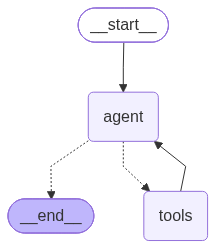

In [7]:
# To see the graph’s connection visually
from IPython.display import Image,display
display(Image(single_app.get_graph().draw_mermaid_png()))

In [8]:
TEST_QUERIES = [
    'What is the price of milk and is it in stock?',
    'I want to return a TV I bought 10 days ago -- what is the policy?',
    'Check my order WM-2024-002 please.',
    'Find chicken breast and check if it is available at the store.',
]

single_results = []
print('Running single-agent on Walmart queries...')
print('=' * 60)

for i, query in enumerate(TEST_QUERIES, 1):
    start = time.time()
    state = single_app.invoke({'messages': [HumanMessage(content=query)]})
    latency = round(time.time() - start, 2)
    final = state['messages'][-1].content
    tool_rounds = sum(1 for m in state['messages']
                      if hasattr(m, 'tool_calls') and m.tool_calls)
    single_results.append({
        'query': query, 'answer': final,
        'latency_sec': latency, 'tool_rounds': tool_rounds,
    })
    print(f'Q{i}: {query}')
    print(f'A : {final[:220]}')
    print(f'   Latency: {latency}s | Tool-call rounds: {tool_rounds}')
    print()

Running single-agent on Walmart queries...
Q1: What is the price of milk and is it in stock?
A : The Great Value Whole Milk (1 gallon) is priced at $3.98 and is available in Aisle 12. Currently, there are 24 units in stock at the Bentonville, AR store.
   Latency: 8.11s | Tool-call rounds: 2

Q2: I want to return a TV I bought 10 days ago -- what is the policy?
A : You can return the TV within 15 days of purchase, provided you have the receipt. Make sure to bring the receipt with you to process the return.
   Latency: 5.88s | Tool-call rounds: 1

Q3: Check my order WM-2024-002 please.
A : Your order with ID WM-2024-002 is currently out for delivery and is expected to arrive today by 8 PM.
   Latency: 4.47s | Tool-call rounds: 1

Q4: Find chicken breast and check if it is available at the store.
A : The Great Value Chicken Breast (3lb) is currently out of stock at your nearest store (Store 042). However, it is available for online order. You can find it in Aisle 4 when it is back in sto

## When Single-Agent Design Breaks Down

| Failure Mode | Description | Walmart Example |
|---|---|---|
| **Context overload** | Too many tools + long history degrades LLM reasoning | One agent with 20 tools: products, HR, logistics, fraud, supplier portal |
| **Skill mismatch** | One LLM cannot be expert in all domains simultaneously | Same agent answering 'find milk' and 'explain ESG audit scoring for suppliers' |
| **No parallelism** | Independent sub-tasks execute sequentially | Checking inventory at 5 store locations one at a time |
| **Single point of failure** | Any step failure aborts the entire interaction | Inventory API timeout kills a simple price-lookup query |
| **Governance boundary violation** | One agent can access data it should not see | Customer-facing agent has read access to supplier contracts |

The five-dimension scoring model below helps you decide when to split into multiple agents.

In [9]:
# Multi-Agent Design -- Coordinator + Specialists

## Multi-Agent Design -- Coordinator + Specialists

Split the single agent into a coordinator and two domain specialists.

```
Customer Query
      |
  [Coordinator]  -- classifies intent (PRODUCT vs SERVICE)
      |
  +---+---+
  |       |
[Product  [Service
 Agent]    Agent]
  |         |
  +----+----+
       |
    [END]
```

Each specialist has a smaller tool set and a tighter system prompt.
The coordinator adds ~100-200ms overhead but reduces per-agent context size
and enforces domain-level governance isolation.

In [10]:
class MultiAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    route: str

PRODUCT_TOOLS = [search_product, check_inventory]
SERVICE_TOOLS = [get_policy, get_order_status]

llm_product = llm.bind_tools(PRODUCT_TOOLS)
llm_service = llm.bind_tools(SERVICE_TOOLS)

COORDINATOR_PROMPT = (
    'Classify the customer query into exactly one category. '
    'Reply with only the single word PRODUCT or SERVICE. '
    'PRODUCT: questions about products, prices, inventory, availability. '
    'SERVICE: questions about orders, returns, shipping, or store policies.'
)

def coordinator_node(state: MultiAgentState) -> dict:
    query = state['messages'][-1].content
    resp = llm.invoke([
        SystemMessage(content=COORDINATOR_PROMPT),
        HumanMessage(content=query),
    ])
    route = 'product' if 'PRODUCT' in resp.content.upper() else 'service'
    return {'route': route}

def route_decision(state: MultiAgentState) -> str:
    return state['route']

def _run_specialist(state, specialist_llm, tools, system_prompt):
    msgs = [SystemMessage(content=system_prompt)] + state['messages']
    resp = specialist_llm.invoke(msgs)
    if hasattr(resp, 'tool_calls') and resp.tool_calls:
        tool_out = ToolNode(tools).invoke({'messages': [resp]})
        final = specialist_llm.invoke(msgs + [resp] + tool_out['messages'])
        return {'messages': [final]}
    return {'messages': [resp]}

def product_agent_node(state: MultiAgentState) -> dict:
    return _run_specialist(
        state, llm_product, PRODUCT_TOOLS,
        'You are a Walmart product specialist. Help customers find products and check inventory.',
    )

def service_agent_node(state: MultiAgentState) -> dict:
    return _run_specialist(
        state, llm_service, SERVICE_TOOLS,
        'You are a Walmart customer service specialist. Handle order tracking, returns, and policies.',
    )

multi_graph = StateGraph(MultiAgentState)
multi_graph.add_node('coordinator',    coordinator_node)
multi_graph.add_node('product_agent',  product_agent_node)
multi_graph.add_node('service_agent',  service_agent_node)
multi_graph.set_entry_point('coordinator')
multi_graph.add_conditional_edges(
    'coordinator', route_decision,
    {'product': 'product_agent', 'service': 'service_agent'},
)
multi_graph.add_edge('product_agent', END)
multi_graph.add_edge('service_agent', END)
multi_app = multi_graph.compile()

print('Multi-agent graph compiled.')
print('Nodes:', list(multi_graph.nodes.keys()))

Multi-agent graph compiled.
Nodes: ['coordinator', 'product_agent', 'service_agent']


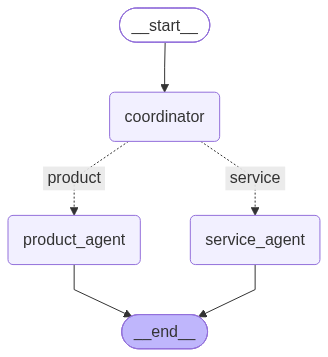

In [11]:
# To see the graph’s connection visually
from IPython.display import Image,display
display(Image(multi_app.get_graph().draw_mermaid_png()))

In [12]:
multi_results = []
print('Running multi-agent on Walmart queries...')
print('=' * 60)

for i, query in enumerate(TEST_QUERIES, 1):
    start = time.time()
    state = multi_app.invoke({'messages': [HumanMessage(content=query)], 'route': ''})
    latency = round(time.time() - start, 2)
    final = state['messages'][-1].content
    multi_results.append({
        'query': query, 'answer': final,
        'latency_sec': latency, 'route': state.get('route', '?'),
    })
    print(f'Q{i}: {query}')
    print(f'   Route: {state.get("route", "?").upper()}')
    print(f'   A: {final[:220]}')
    print(f'   Latency: {latency}s')
    print()

Running multi-agent on Walmart queries...
Q1: What is the price of milk and is it in stock?
   Route: PRODUCT
   A: 
   Latency: 4.48s

Q2: I want to return a TV I bought 10 days ago -- what is the policy?
   Route: SERVICE
   A: You can return the TV you bought within 15 days as it falls under the electronics category. Please make sure to have your receipt available when you process the return.
   Latency: 6.2s

Q3: Check my order WM-2024-002 please.
   Route: SERVICE
   A: Your order (WM-2024-002) is currently out for delivery and is expected to arrive today by 8 PM.
   Latency: 4.31s

Q4: Find chicken breast and check if it is available at the store.
   Route: PRODUCT
   A: 
   Latency: 3.94s



## Decision Scoring Model

Score each dimension 1 (low) to 3 (high). Use the total to guide the architecture decision.

| Dimension | 1 | 2 | 3 |
|---|---|---|---|
| **Tool count** | 1-3 tools | 4-6 tools | 7+ tools |
| **Domain breadth** | Single domain | 2 domains | 3+ domains |
| **Parallelism needed** | None | Optional | Required for SLA |
| **Governance isolation** | Not required | Preferred | Mandatory |
| **Failure blast radius** | Acceptable | Moderate concern | Unacceptable |

Total < 7: Single agent.
Total 7-9: Single agent with defensive design (error handling, tool namespacing).
Total >= 10: Multi-agent recommended.

In [14]:
def score_agent_architecture(use_case: dict) -> dict:
    tool_score       = min(3, max(1, (use_case.get('tool_count', 1) - 1) // 3 + 1))
    domain_score     = min(3, use_case.get('domain_count', 1))
    parallel_score   = {'none': 1, 'optional': 2, 'required': 3}.get(use_case.get('parallelism', 'none'), 1)
    governance_score = {'not_required': 1, 'preferred': 2, 'mandatory': 3}.get(use_case.get('governance', 'not_required'), 1)
    blast_score      = {'acceptable': 1, 'moderate': 2, 'unacceptable': 3}.get(use_case.get('blast_radius', 'acceptable'), 1)
    total = tool_score + domain_score + parallel_score + governance_score + blast_score
    if total >= 10:
        rec = 'MULTI-AGENT'
    elif total >= 7:
        rec = 'SINGLE-AGENT with defensive design'
    else:
        rec = 'SINGLE-AGENT'
    return {
        'scores': {
            'tool_count': tool_score, 'domain_breadth': domain_score,
            'parallelism': parallel_score, 'governance_isolation': governance_score,
            'blast_radius': blast_score,
        },
        'total': total, 'recommendation': rec,
    }

walmart_case = {
    'name': 'Walmart Retail Assistant',
    'tool_count': 4,
    'domain_count': 2,
    'parallelism': 'optional',
    'governance': 'preferred',
    'blast_radius': 'moderate',
}

result = score_agent_architecture(walmart_case)
print(f'Use case: {walmart_case["name"]}')
print()
for dim, score in result['scores'].items():
    print(f'  {dim:<26}: {score}/3')
print(f'  {"TOTAL":<26}: {result["total"]}/15')
print()
print(f'Recommendation: {result["recommendation"]}')

Use case: Walmart Retail Assistant

  tool_count                : 2/3
  domain_breadth            : 2/3
  parallelism               : 2/3
  governance_isolation      : 2/3
  blast_radius              : 2/3
  TOTAL                     : 10/15

Recommendation: MULTI-AGENT


In [15]:
# Single-Agent vs Multi-Agent -- Side-by-Side

avg_single = sum(r['latency_sec'] for r in single_results) / len(single_results)
avg_multi  = sum(r['latency_sec'] for r in multi_results)  / len(multi_results)

hdr = f"{'Metric':<32} {'Single-Agent':>14} {'Multi-Agent':>14}"
print(hdr)
print('-' * len(hdr))
print(f"{'Avg latency (sec)':<32} {avg_single:>14.2f} {avg_multi:>14.2f}")
print(f"{'LLM calls per query':<32} {'1 (all tools)':>14} {'2 (coord+spec)':>14}")
print(f"{'Context per LLM call':<32} {'4 tools':>14} {'2 tools':>14}")
print(f"{'Governance isolation':<32} {'None':>14} {'By domain':>14}")
print(f"{'Blast radius on failure':<32} {'Full query':>14} {'Sub-agent only':>14}")
print(f"{'Parallelism possible':<32} {'No':>14} {'Yes':>14}")
print(f"{'Infra complexity':<32} {'Low':>14} {'Medium':>14}")
print(f"{'Recommended for Walmart RA':<32} {'4 tools / 2 domains':>14} {'Scalable baseline':>14}")

Metric                             Single-Agent    Multi-Agent
--------------------------------------------------------------
Avg latency (sec)                          6.22           4.73
LLM calls per query               1 (all tools) 2 (coord+spec)
Context per LLM call                    4 tools        2 tools
Governance isolation                       None      By domain
Blast radius on failure              Full query Sub-agent only
Parallelism possible                         No            Yes
Infra complexity                            Low         Medium
Recommended for Walmart RA       4 tools / 2 domains Scalable baseline


In [16]:
lines = [
    'AGENT DESIGN WORKSHEET',
    'Advanced Agentic AI -- Production Engineering | India Track',
    'Module 2 -- Agent Architecture and Orchestration',
    '=' * 60,
    '',
    'USE CASE: Walmart Retail Assistant',
    '',
    'AGENT ANATOMY',
    '  Planning   : LangGraph graph topology encodes step sequence',
    '  Memory     : Shared message list in AgentState (in-session)',
    '  State      : TypedDict -- messages + route (multi-agent)',
    '  Tool Calling: 4 tools split 2+2 across specialists (multi)',
    '  Action     : Final specialist LLM response grounded in tool output',
    '',
    'DECISION SCORING (Walmart Retail Assistant)',
    f'  Tool count score        : {result["scores"]["tool_count"]}/3',
    f'  Domain breadth score    : {result["scores"]["domain_breadth"]}/3',
    f'  Parallelism score       : {result["scores"]["parallelism"]}/3',
    f'  Governance isolation    : {result["scores"]["governance_isolation"]}/3',
    f'  Blast radius score      : {result["scores"]["blast_radius"]}/3',
    f'  TOTAL                   : {result["total"]}/15',
    f'  RECOMMENDATION          : {result["recommendation"]}',
    '',
    'LATENCY COMPARISON',
    f'  Single-agent avg        : {avg_single:.2f}s',
    f'  Multi-agent avg         : {avg_multi:.2f}s',
    f'  Coordinator overhead    : ~{max(0, avg_multi - avg_single):.2f}s',
    '',
    'ARCHITECTURE DECISION',
    '  Selected: Multi-Agent (Coordinator + Product Specialist + Service Specialist)',
    '  Rationale:',
    '    - Separates product domain from customer service domain',
    '    - Reduces per-agent context: each specialist sees only 2 tools',
    '    - Enables independent scaling and failure isolation per domain',
    '    - Coordinator overhead justified by governance and blast-radius reduction',
]

out = Path('agent_design_worksheet.txt')
out.write_text('\n'.join(lines))
print(f'Deliverable written: {out}')

Deliverable written: agent_design_worksheet.txt


## Summary

| Decision | Guideline |
|---|---|
| Single agent | 1-2 domains, 1-3 tools, no governance concern |
| Multi-agent | 3+ domains or 7+ tools, governance isolation needed |
| Coordinator overhead | Adds ~100-200ms -- worth it when blast radius is a concern |
| State design | Keep TypedDict minimal; add fields only when routing logic requires them |

**Next: IN05** implements the same Walmart use case in three orchestration patterns
(Sequential, Router, Supervisor) and measures the trade-offs between them.